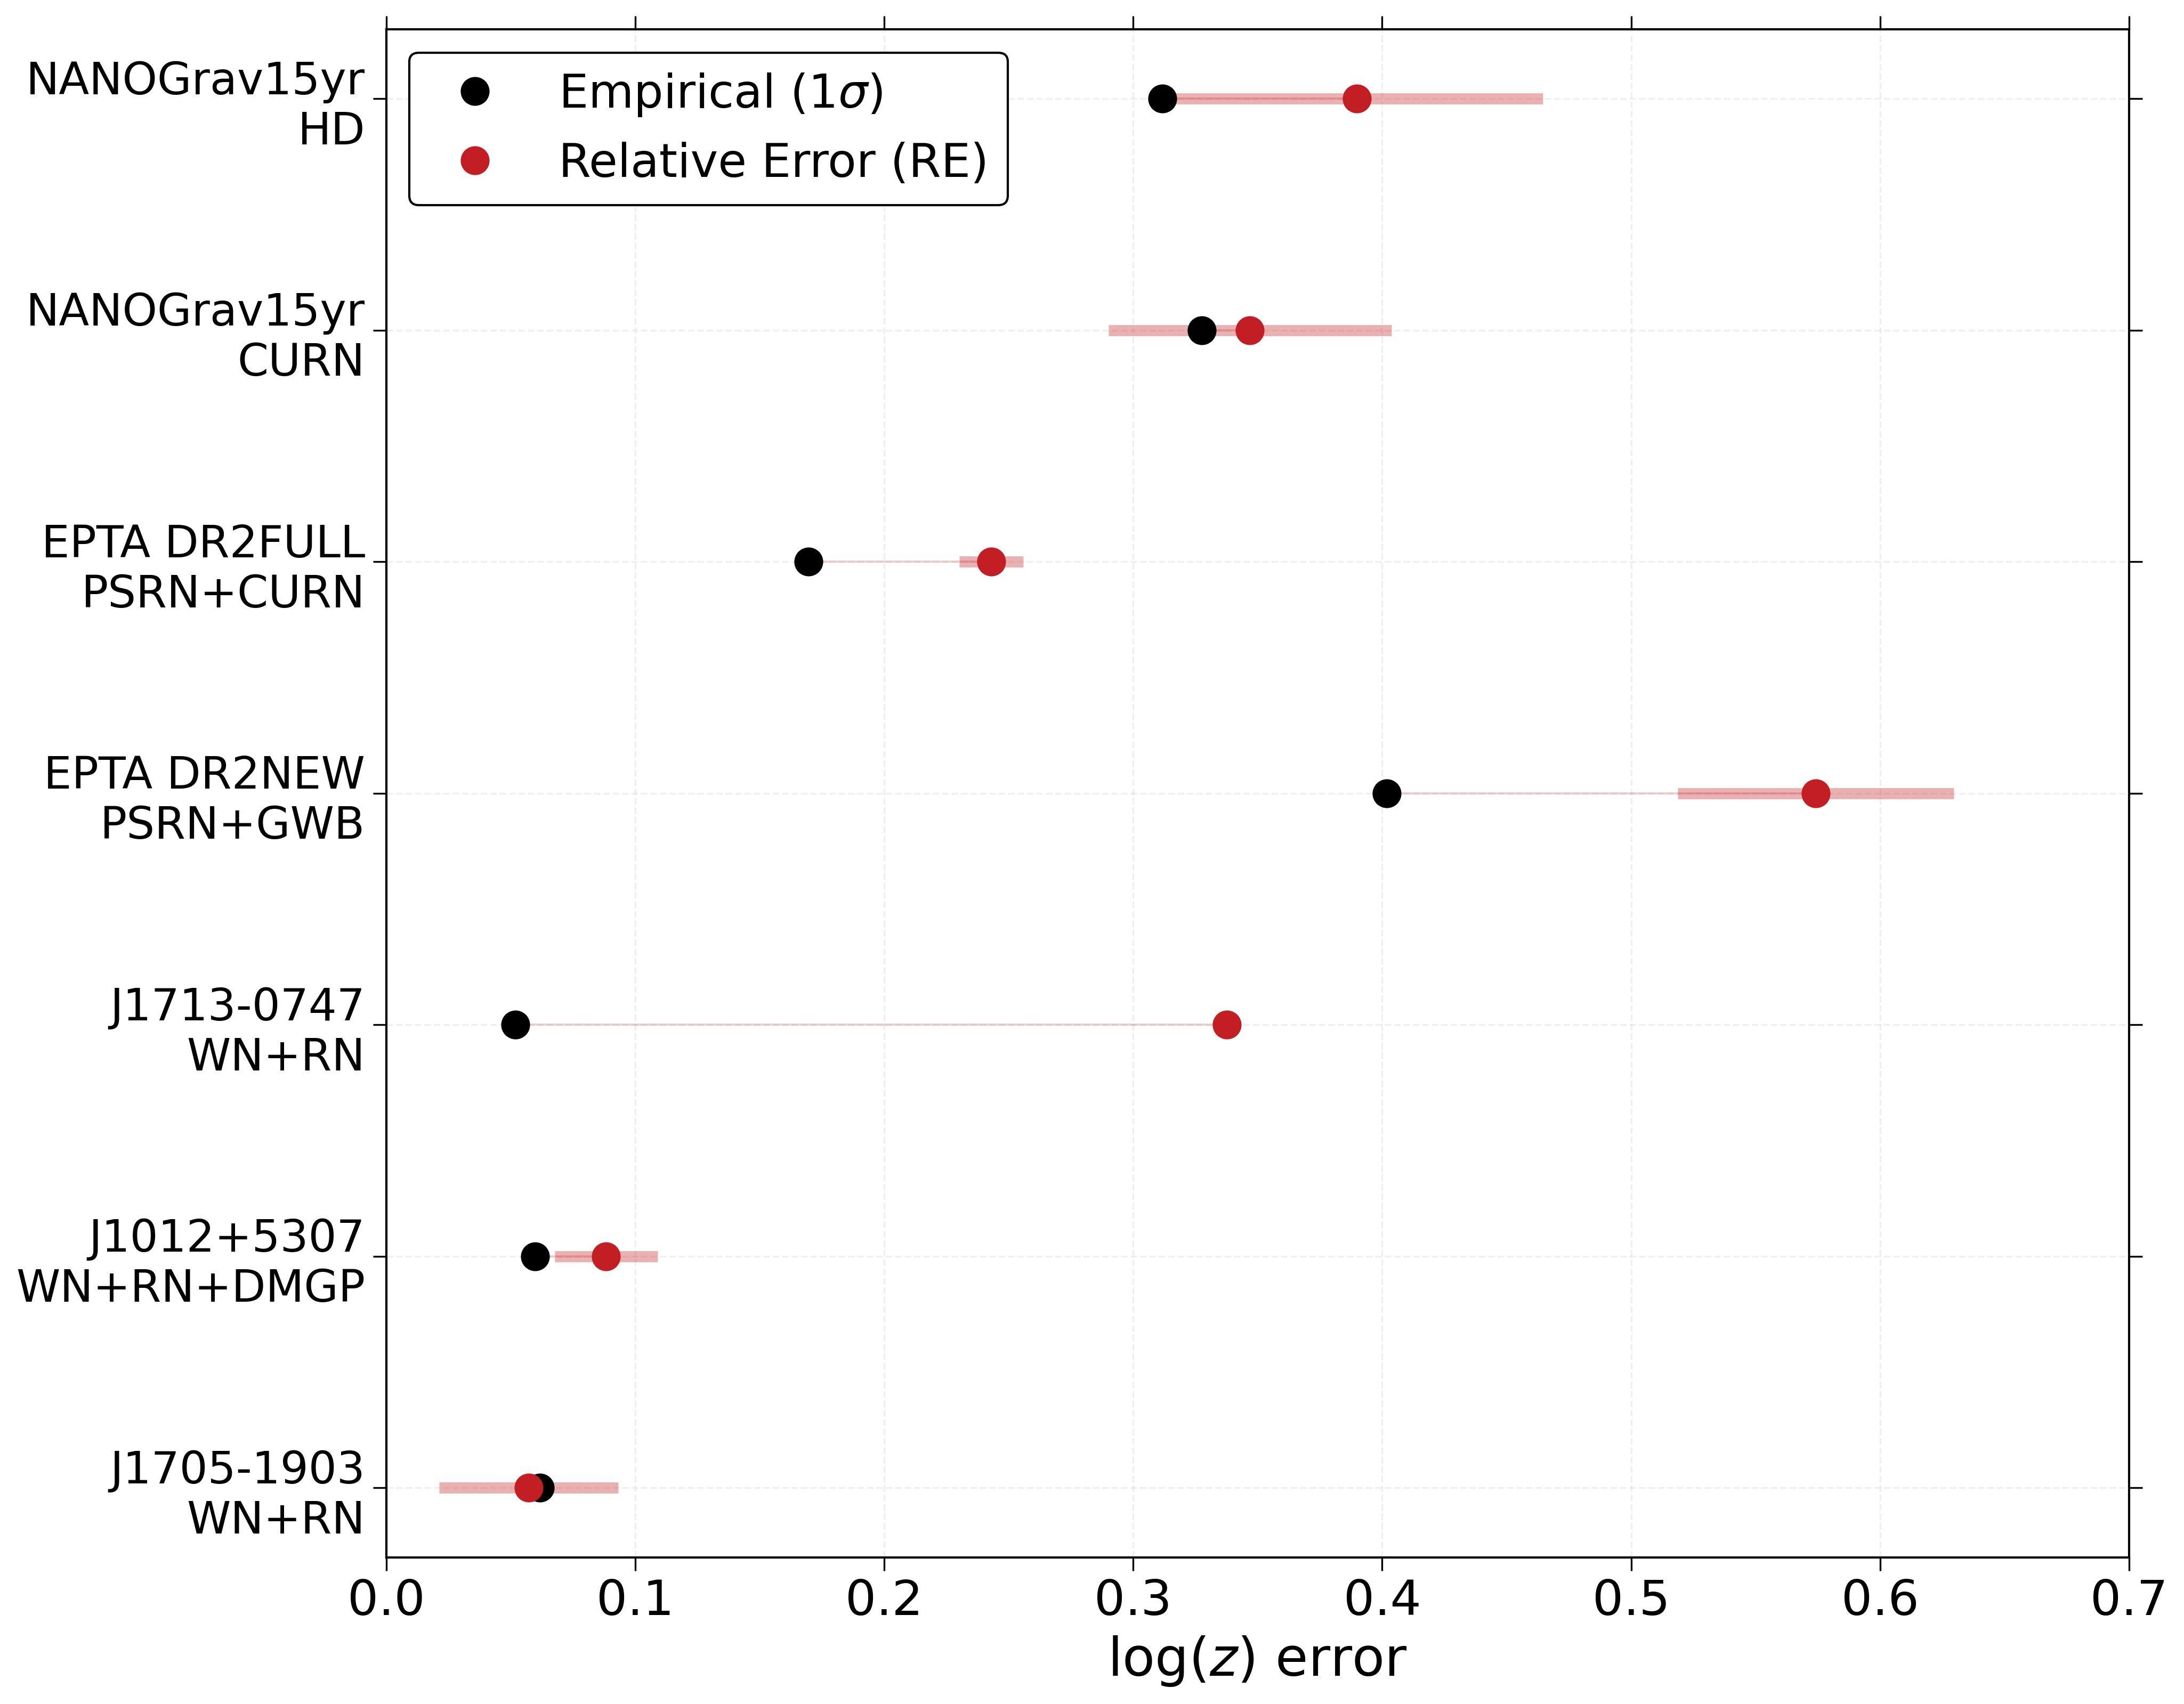

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from typing import Dict, List
import textwrap
import matplotlib as mpl


# --- global style (adjust once, reuse everywhere) ---
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 18,
    "axes.labelsize": 24,
    "axes.titlesize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "axes.linewidth": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
})

def wrap_label(s, width=14):
    # allow breaks at '+' by padding with spaces first
    s = s.replace(' ', '\n')
    return "\n".join(textwrap.wrap(s, width=width, break_long_words=False, break_on_hyphens=False))

def summarize_errors_np(model_arrays: Dict[str, np.ndarray], scale: float = 1.0, sort=None):
    """
    Parameters
    ----------
    model_arrays : dict[str, np.ndarray]
        For each model name, an array of shape (n, 2):
        [:,0] = log(z) per replicate
        [:,1] = per-replicate approximate error (SE) for that estimate
    scale : float
        Multiplier applied to log(z) before computing empirical std (default 100).

    Returns
    -------
    summary : dict of numpy arrays
        keys: names, empirical, approx_med, approx_q1, approx_q3, ratio, order, scale
    """
    names: List[str] = []
    empirical: List[float] = []
    approx_med: List[float] = []
    approx_q1: List[float] = []
    approx_q3: List[float] = []
    std: List[float] = []


    for name, arr in model_arrays.items():
        if arr.ndim != 2 or arr.shape[1] != 2:
            raise ValueError(f"{name}: expected array shape (n,2), got {arr.shape}")
        logz = arr[:, 0].astype(float)
        approx = arr[:, 1].astype(float)

        est = scale * logz
        emp = np.nanstd(est, ddof=1)                 # empirical error
        med = np.nanmedian(approx)                    # median approx error
        q1, q3 = np.nanquantile(approx, [0.25, 0.75])# IQR for approx error
        std_app = np.std(approx)
        if np.isfinite(emp) and np.isfinite(med):
            names.append(name)
            empirical.append(emp)
            approx_med.append(med)
            approx_q1.append(q1)
            approx_q3.append(q3)
            std.append(std_app)

    names = np.array(names)
    empirical = np.array(empirical)
    approx_med = np.array(approx_med)
    approx_q1 = np.array(approx_q1)
    approx_q3 = np.array(approx_q3)
    std = np.array(std)
    ratio = empirical / approx_med
    order = np.argsort(empirical)[::-1]  # sort models by empirical error (desc)
    if sort is None:
        order = np.arange(len(names))              # <— keep dict insertion order
    elif sort == "empirical":
        order = np.argsort(empirical)[::-1]        # (optional) sort by empirical
    elif sort == "name":
        order = np.argsort(np.char.lower(names))   # (optional) sort by name
    else:
        raise ValueError("sort must be None|'empirical'|'name'")
    return {
        "names": names,
        "empirical": empirical,
        "approx_med": approx_med,
        "approx_q1": approx_q1,
        "approx_q3": approx_q3,
        "ratio": ratio,
        "order": order,
        "scale": scale,
        "std":std,
    }

def plot_dumbbell_np(summary, title="Approx vs Empirical error by model",
                     log_scale=False, max_models=60, xlim=None, xticks=None):
    idx = summary["order"][:max_models][::-1]
    names = summary["names"][idx]
    emp   = summary["empirical"][idx]
    med   = summary["approx_med"][idx]
    q1    = summary["approx_q1"][idx]
    q3    = summary["approx_q3"][idx]
    std   = summary["std"][idx]
    y = np.arange(len(idx))
    fig, ax = plt.subplots(figsize=(14, 11))
    # ax.hlines(y, q1, q3,color='#c31e23', linewidth=6, alpha=0.25)
    ax.hlines(y, med-std, med+std,color='#c31e23', linewidth=5, alpha=0.35)

    ax.hlines(y, med, emp,color='#c31e23', linewidth=1, alpha=0.2)
    ax.plot(emp, y, 'o',color="black",markersize=12, label=r'Empirical ($1\sigma$)')
    ax.plot(med, y, 'o',color='#c31e23',markersize=12, label='Relative Error (RE)')
    ax.set_yticks(y)
    wrapped = [wrap_label(s, width=14) for s in names]
    ax.set_yticklabels(wrapped, ha="right")  # right-align looks cleaner for multi-line

    # --- lock x-axis here ---
    if log_scale:
        ax.set_xscale("log")
    if xlim is not None:           # e.g., xlim=(0.05, 0.50)
        ax.set_xlim(*xlim)
    if xticks is not None:         # optional: custom ticks
        ax.set_xticks(xticks)

    ax.set_xlabel(r"$\log(z)$ error")
    # ax.set_title(title)
    leg = ax.legend(frameon=True,
    loc="upper left",
    fontsize=21, )
    leg.get_frame().set_facecolor('white')
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_alpha(1.0)


    ax.grid(linestyle='--', alpha=0.2)
    fig.tight_layout()
    return fig, ax



def plot_calibration_np(summary: dict, title: str = "Calibration: empirical vs approx error"):
    """
    Scatter of (approx median, empirical) across models with 45° line.
    """
    x = summary["approx_med"]
    y = summary["empirical"]

    # Bounds for the 45° line (avoid nonpositive on log axes)
    x_pos = x[x > 0]
    y_pos = y[y > 0]
    lo = min(x_pos.min(), y_pos.min()) if len(x_pos) and len(y_pos) else 1e-6
    hi = max(x_pos.max(), y_pos.max()) if len(x_pos) and len(y_pos) else 1.0

    fig, ax = plt.subplots(figsize=(10, 14))
    ax.scatter(x, y, alpha=0.9)
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)

    ax.set_xlabel("RMSE (median)")
    ax.set_ylabel("Empirical error (std)")
    ax.set_title(title)
    ax.set_xscale("log")
    ax.set_yscale("log")
    fig.tight_layout()
    return fig, ax

J1012_5307_rn_dmgp = np.loadtxt("./evidences/J1012+5307_rn_dmgp_morphz/logz_morph_z_pair_silverman.txt",skiprows=1,dtype=float)
J1705_1903_rn = np.loadtxt("./evidences/J1705-1903_rn_morphz/logz_morph_z_pair_silverman.txt",skiprows=1,dtype=float)
J1713_074_rn = np.loadtxt("./evidences/J1713+074_rn_morphz/logz_morph_z_pair_silverman.txt",skiprows=1,dtype=float)
curn = np.loadtxt("./evidences/curn_morph/logz_morph_z_pair_silverman.txt",skiprows=1,dtype=float)
hd = np.loadtxt("./evidences/hd_morph/logz_morph_z_2_group_silverman.txt",skiprows=1,dtype=float)
epta_curn = np.loadtxt("./evidences/dr2full_curn/logz_morph_z_pair_silverman.txt",skiprows=1,dtype=float)
epta_gwb = np.loadtxt("./evidences/dr2new_HD/logz_morph_z_pair_cv_iso.txt",skiprows=1,dtype=float)




# ---- Example usage ----

data = {
   "NANOGrav15yr HD": hd,
  "NANOGrav15yr CURN": curn,
  "EPTA DR2FULL PSRN+CURN": epta_curn,
  "EPTA DR2NEW PSRN+GWB": epta_gwb,
  "J1713-0747 WN+RN":J1713_074_rn,
  "J1012+5307 WN+RN+DMGP": J1012_5307_rn_dmgp,  # shape (n, 2) => [log(z), approx_err]
  "J1705-1903 WN+RN":J1705_1903_rn,
  # ...
}
summary = summarize_errors_np(data, scale=1)  # 100·log(z)
# plot_dumbbell_np(summary)         # main “all models in one” plot
# plot_calibration_np(summary)      # optional calibration check

# Linear axis fixed between 0.04 and 0.50
plot_dumbbell_np(summary, xlim=(0, 0.7))


# plot_calibration_np(summary)      # optional calibration check
plt.savefig("./plots/PTA_rsme.pdf",dpi=300)
plt.show()


In [ ]:
import morphZ
from scipy.special import logsumexp

def kl_from_log_probs(log_p, log_q):
    log_p = np.asarray(log_p, dtype=float)
    log_q = np.asarray(log_q, dtype=float)

    # p = exp(log_p)
    p = np.exp(log_p)

    # mask out entries where p == 0 to avoid 0 * log(0/·)
    mask = p > 0

    # if q == 0 where p > 0, KL is infinite
    if np.any(np.isneginf(log_q[mask])):  # log(0) = -inf
        return np.inf

    return np.sum(p[mask] * (log_p[mask] - log_q[mask]))

def kl_from_unnormalized_logs(tilde_log_p, tilde_log_q):
    tilde_log_p = np.asarray(tilde_log_p, float)
    tilde_log_q = np.asarray(tilde_log_q, float)

    logZ_p = logsumexp(tilde_log_p)
    logZ_q = logsumexp(tilde_log_q)

    log_p = tilde_log_p - logZ_p
    log_q = tilde_log_q - logZ_q

    return kl_from_log_probs(log_p, log_q)

samples = [] # need to be defined as an array of shape (n_samples, n_params) for the morphs to work
log_prob = [] # need to be defined as an array of shape (n_samples,) for the kl_from_unnormalized_logs function to work 
params = [] # need to be defined as a list of parameter names corresponding to the columns in samples
morph_1 = morphZ.Morph_Indep(samples)
morph_1_logpdf = morph_1.logpdf_kde(samples.T)

D_kl_1 = kl_from_unnormalized_logs(log_prob, morph_1_logpdf)
print('D_kl group 1:',D_kl_1)

morph_2 = morphZ.Morph_Group(samples,"./figure 3/second/dr2full_curn_2/params_2-order_TC.json",param_names=params)
morph_2_logpdf = morph_2.logpdf(samples.T)
# print('morph_2_logpdf:',len(morph_2_logpdf))
D_kl_2 = kl_from_unnormalized_logs(log_prob, morph_2_logpdf)
print('D_kl group 2:',D_kl_2)
# print('chi2 group 2:',chi2_2)
morph_3 = morphZ.Morph_Group(samples,"./figure 3/dr2full_curn_3/params_3-order_TC.json",param_names=params)
morph_3_logpdf = morph_3.logpdf(samples.T)
D_kl_3 = kl_from_unnormalized_logs(log_prob, morph_3_logpdf)
print('D_kl group 3:',D_kl_3)
# print('chi2 group 3:',chi2_3)

morph_4 = morphZ.Morph_Group(samples,"./figure 3/dr2full_curn_4/params_4-order_TC.json",param_names=params)
morph_4_logpdf = morph_4.logpdf(samples.T)
D_kl_4 = kl_from_unnormalized_logs(log_prob, morph_4_logpdf)
print('D_kl group 4:',D_kl_4)
# print('chi2 group 4:',chi2_4)

# save D_kl values to a file for later use
with open("./figure 3/D_kl_groups.txt", "w") as f:
    f.write(f"Group 1 D_kl: {D_kl_1}\n")
    f.write(f"Group 2 D_kl: {D_kl_2}\n")
    f.write(f"Group 3 D_kl: {D_kl_3}\n")
    f.write(f"Group 4 D_kl: {D_kl_4}\n")    


Group 1 logz: (100, 2)


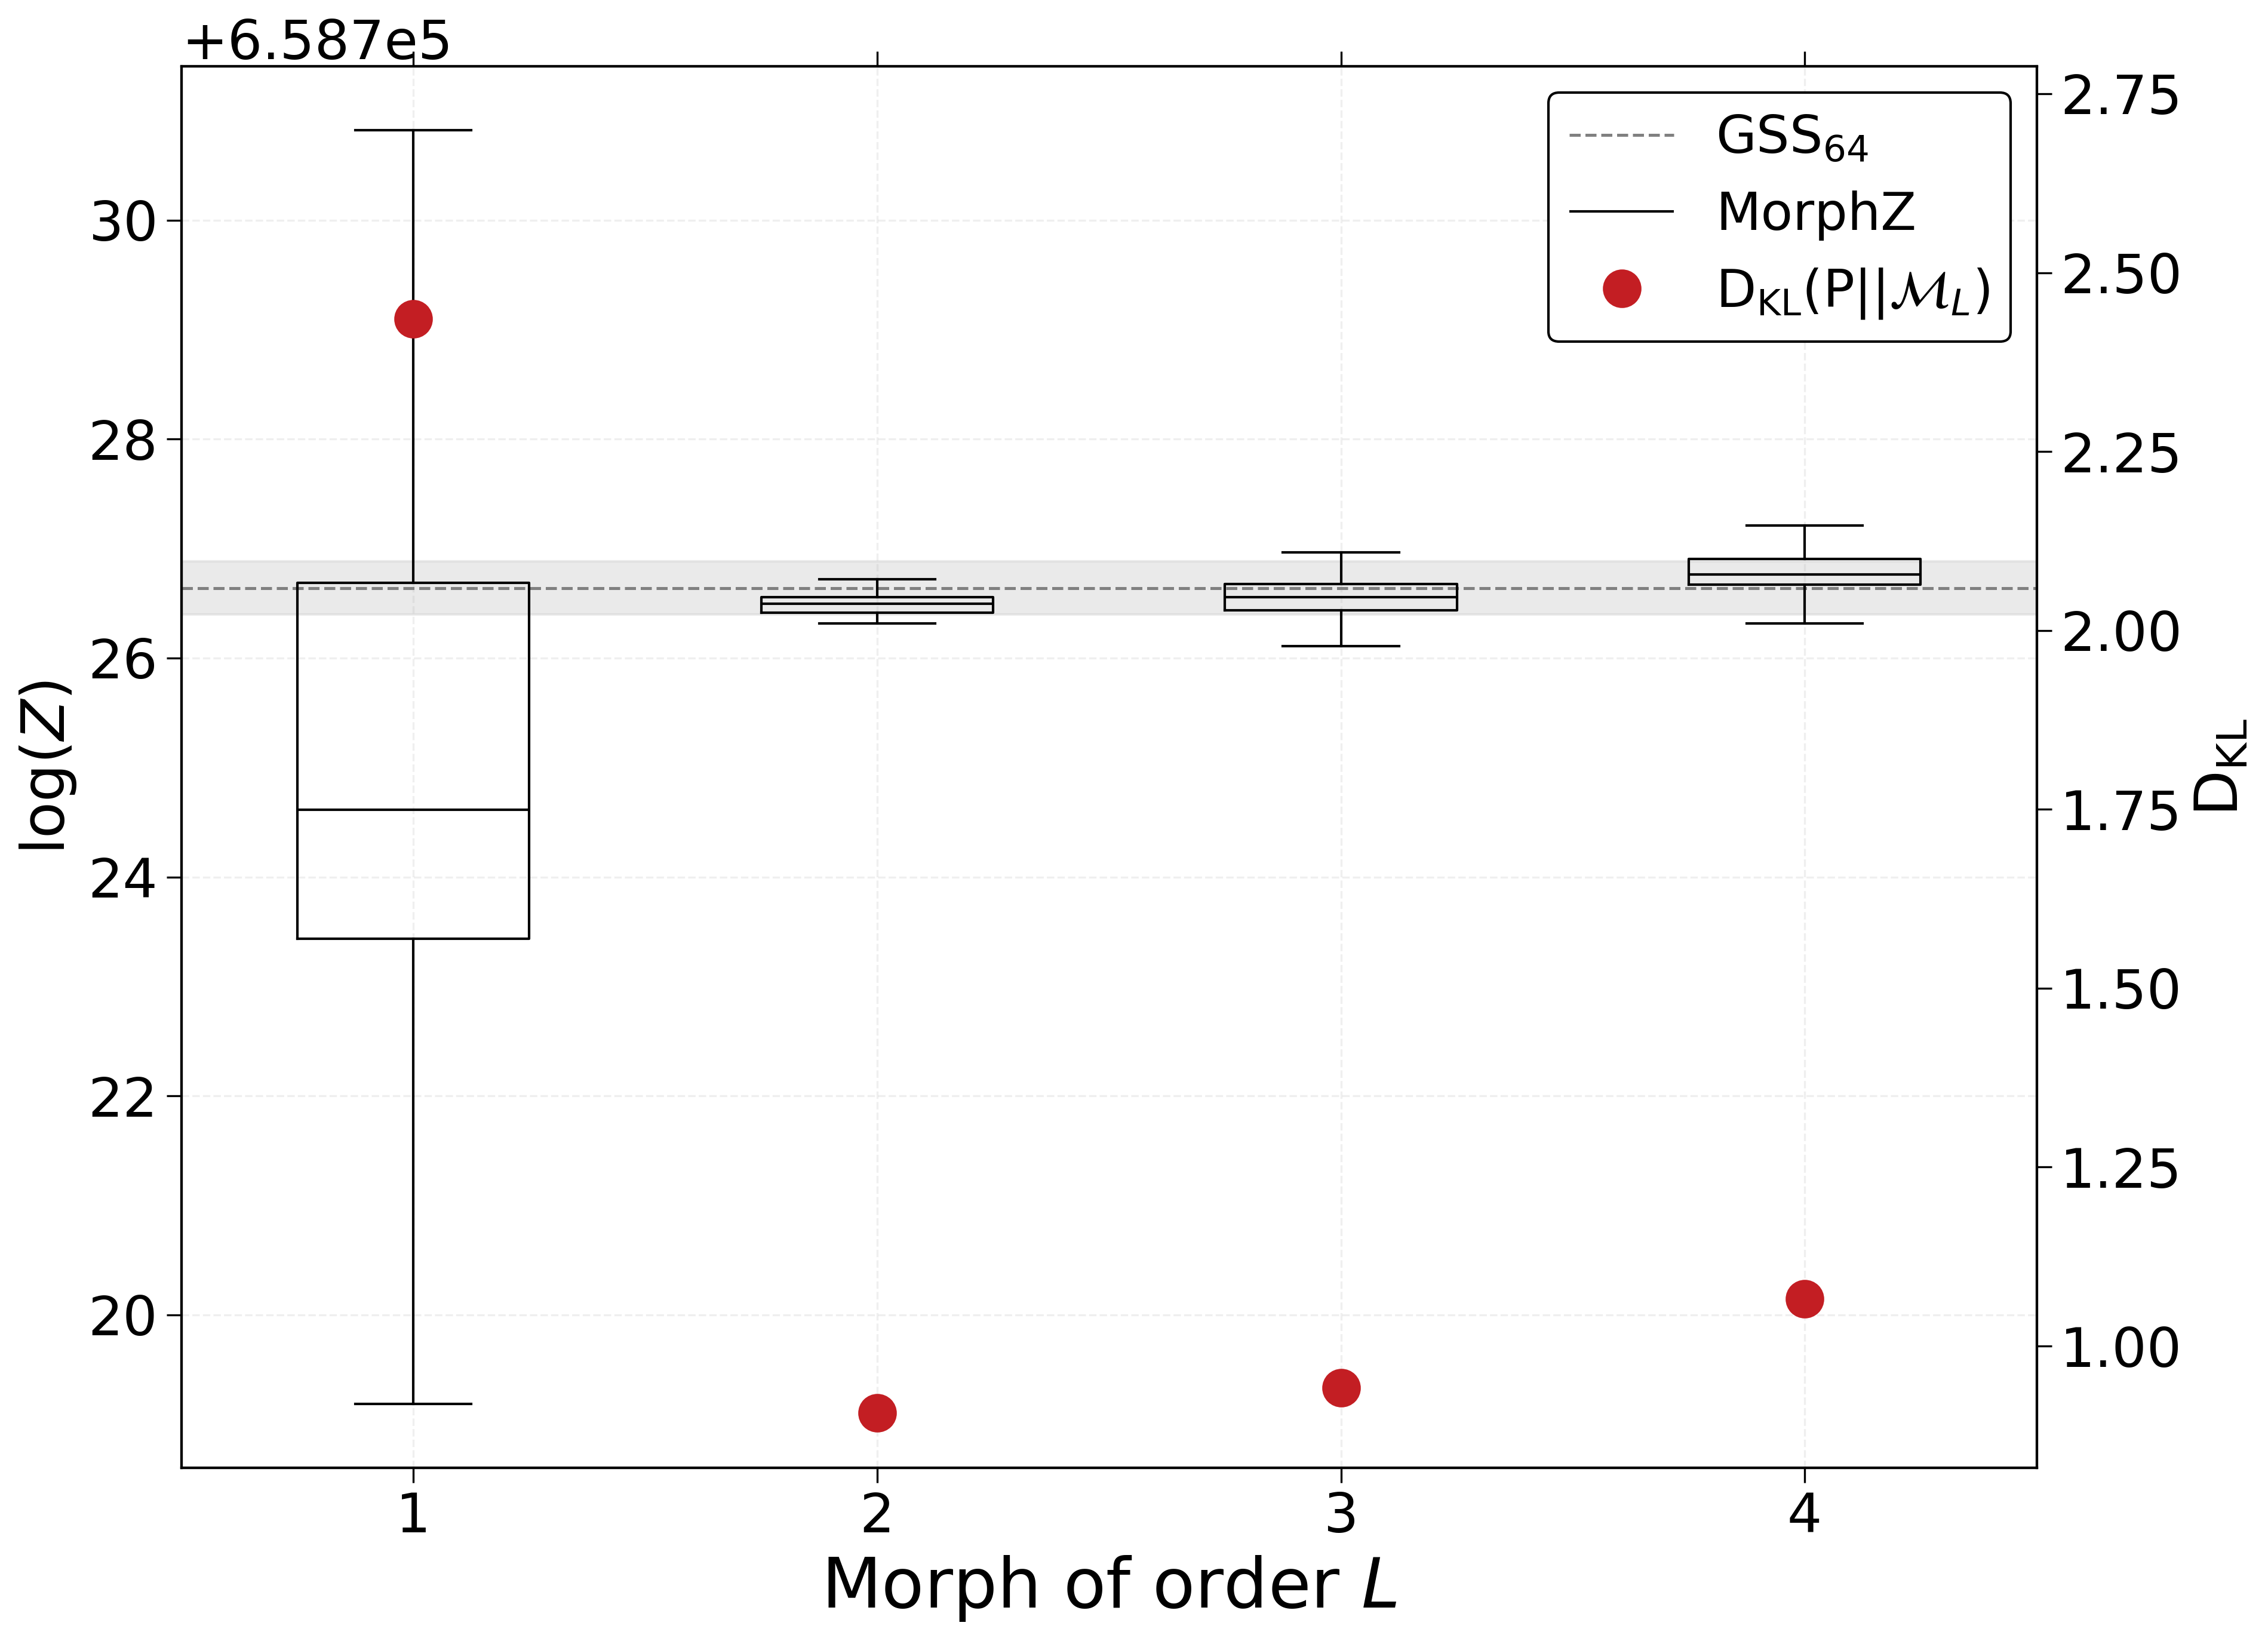

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

# --- global style (adjust once, reuse everywhere) ---
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 18,
    "axes.labelsize": 24,
    "axes.titlesize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 20,
    "axes.linewidth": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
})

# --- load data (your paths) ---
group_1 = np.loadtxt(
    './figure 3/dr2full_curn_1/logz_morph_z_indep_silverman.txt',
    skiprows=1, dtype=float
)
group_2 = np.loadtxt(
    './figure 3/dr2full_curn_2/logz_morph_z_2_group_silverman.txt',
    skiprows=1, dtype=float
)
group_3 = np.loadtxt(
    './figure 3/dr2full_curn_3/logz_morph_z_3_group_silverman.txt',
    skiprows=1, dtype=float
)
group_4 = np.loadtxt(
    './figure 3/dr2full_curn_4/logz_morph_z_4_group_silverman.txt',
    skiprows=1, dtype=float
)
print('Group 1 logz:', group_1.shape)

curn_log_z = np.loadtxt('./figure 3/DR2full_curn_30000samp_log_z_64T.txt',dtype=float)

Gss_value = curn_log_z.mean()
Gss_value_std = curn_log_z.std()

data = [group_1[:, 0], group_2[:, 0], group_3[:, 0], group_4[:, 0]]

# --- D_KL values for each morph order (ensure this is defined beforehand) ---
# Example: replace with your actual D_kl_1, ... values
d_kl = np.genfromtxt("./figure 3/D_kl_groups.txt", dtype=float, usecols=-1)
x_pos = [1, 2, 3, 4]

# --- figure ---
fig, ax = plt.subplots(figsize=(13, 9.5))



# GSS reference line
gss_line = ax.axhline(
    Gss_value,
    xmin=0,
    xmax=5,
    color="grey",
    linestyle="--",
    linewidth=1.2,
    label=r"GSS$_{64}$"
)

# 1σ band around GSS value
lower = Gss_value - Gss_value_std
upper = Gss_value + Gss_value_std

ax.fill_between(
    [0.5, 4.5],
    lower,
    upper,
    color="0.8",
    alpha=0.4,
    zorder=0,
)
bp = ax.boxplot(
    data,
    positions=x_pos,
    widths=0.5,
    patch_artist=False,
    showfliers=False,
    label="MorphZ"
)

# subtle fill colours, consistent lines (currently none set)
colors = []
for patch, c in zip(bp["boxes"], colors):
    patch.set(facecolor=c, alpha=0.7, linewidth=1.0)

for element in ["whiskers", "caps", "medians"]:
    for obj in bp[element]:
        obj.set(linewidth=1.0, color="black")
# axes + labels
ax.set_xticks(x_pos)
ax.set_xticklabels(["1", "2", "3", "4"])
ax.set_xlabel(r"Morph of order $L$",fontsize=28)
ax.set_ylabel(r"$\log (Z)$")
ax.ticklabel_format(style="plain", axis="y")

# --- second axis for D_KL ---
ax2 = ax.twinx()
kl_points = ax2.plot(
    x_pos,
    d_kl,
    marker="o",
    linestyle="None",
    markersize=14,              # big markers
    markerfacecolor="#c31e23",    # hollow
    markeredgecolor="#c31e23",     # red edge
    markeredgewidth=1.5,
    label=r"D$_{\mathrm{KL}}($P$||\mathcal{M}_{L})$",
)
ax2.set_ylabel(r"D$_{\mathrm{KL}}$")
ymin2, ymax2 = ax2.get_ylim()
ax2.set_ylim(ymin2, ymax2 * 1.11)
# ticks = ax2.get_yticks()
# ax2.set_yticks([t for t in ticks if abs(t - 1.6) > 1e-6])


# --- combined legend (boxplot + GSS + KL markers) ---
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles = handles1 + handles2
labels = labels1 + labels2

leg = ax.legend(
    handles,
    labels,
    frameon=True,
    loc="upper right",
    fontsize=21, 
)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_edgecolor("black")   # optional
leg.get_frame().set_alpha(1.0) 
ax.grid(True,linestyle='--', alpha=0.2)

fig.tight_layout()

fig.savefig("./plots/gwb_group_comparison_boxplot.pdf")
plt.show()
